In [17]:
import torch

print(torch.__version__)
print("GPU available:", torch.cuda.is_available())

2.13.0
GPU available: False


## Setup

In [18]:
import sys
from pathlib import Path
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [19]:
from src.training import (
    count_trainable_parameters,
    fit_classifier,
    predict_classifier,
    set_random_seed)

In [20]:
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader
from src.data_processing import chronological_split
from src.datasets import TabularMovieDataset
from src.evaluation import evaluate_classifier
from src.models import TabularMLP
from src.training import fit_classifier, predict_classifier

In [21]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


## Load data

In [40]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(
    project_root / "data/processed/movies_processed.csv",
    parse_dates=["release_date"],
)

# Reserve all 2014+ movies as the chronological test set
development = df[
    df["release_year"] < 2014
].copy()

test = df[
    df["release_year"] >= 2014
].copy()

# Randomly split the pre-2014 development data into train and validation
train, validation = train_test_split(
    development,
    test_size=185,
    stratify=development["flop"],
    random_state=42,
)

# Reset indices for cleaner downstream processing
train = train.reset_index(drop=True)
validation = validation.reset_index(drop=True)
test = test.reset_index(drop=True)

print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

print("\nFlop proportions:")
print("Train:", train["flop"].mean())
print("Validation:", validation["flop"].mean())
print("Test:", test["flop"].mean())

assert len(train) == 559
assert len(validation) == 185
assert len(test) == 113

Train: 559
Validation: 185
Test: 113

Flop proportions:
Train: 0.5813953488372093
Validation: 0.5783783783783784
Test: 0.40707964601769914


In [41]:
# feature extraction
genre_features = [
    column
    for column in df.columns
    if column.startswith("genre_")]
numeric_features = [
    "budget",
    "runtime",
    "director_success_ratio",
    "director_prior_count",
    "actor_success_ratio",
    "actor_prior_count",
    "is_sequel_or_remake",
    "major_studio",
    *genre_features]
categorical_features = [
    "original_language",
    "release_season"]
features = numeric_features + categorical_features
target = "flop"

## Preprocessing

In [42]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())])
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)
x_train = preprocessor.fit_transform(train[features])
x_validation = preprocessor.transform(validation[features])
y_train = train["flop"].to_numpy(dtype=np.float32)
y_validation = validation["flop"].to_numpy(dtype=np.float32)
print("Training shape:", x_train.shape)
print("Validation shape:", x_validation.shape)

Training shape: (559, 37)
Validation shape: (185, 37)


In [43]:
# create datasets and loaders
train_dataset = TabularMovieDataset(
    features=x_train,
    labels=y_train,
)
validation_dataset = TabularMovieDataset(
    features=x_validation,
    labels=y_validation,
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=64,
    shuffle=False,
)

## Create Model

In [44]:
model = TabularMLP(
    input_dim=x_train.shape[1],
    hidden_dim_1=32,
    hidden_dim_2=16,
    dropout=0.3)
print(model)
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad)
print("Trainable parameters:", trainable_parameters)

TabularMLP(
  (network): Sequential(
    (0): Linear(in_features=37, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)
Trainable parameters: 1761


In [45]:
# account for class imbalance with BCEWithLogitsLoss
number_of_hits = int((y_train == 0).sum())
number_of_flops = int((y_train == 1).sum())
positive_weight = torch.tensor(
    [number_of_hits / number_of_flops],
    dtype=torch.float32,
    device=device)
print("Positive-class weight:", positive_weight.item())
loss_function = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight)
loss_function = nn.BCEWithLogitsLoss()

Positive-class weight: 0.7200000286102295


## Train model

In [46]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4)
history = fit_classifier(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    max_epochs=100,
    patience=12)
print(history["epochs_trained"])
print(history["best_validation_loss"])

27
0.6094405547992603


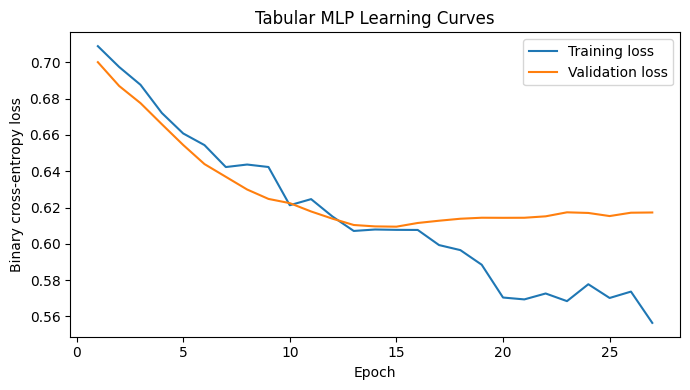

In [47]:
epochs = np.arange(1, history["epochs_trained"] + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], label="Training loss")
plt.plot(
    epochs,
    history["validation_loss"],
    label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Tabular MLP Learning Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
best_epoch = (
    np.argmin(history["validation_loss"]) + 1)
print("Best epoch:", best_epoch)
print(
    "Best validation loss:",
    min(history["validation_loss"]))
print(
    "Final validation loss:",
    history["validation_loss"][-1])

Best epoch: 15
Best validation loss: 0.6094405547992603
Final validation loss: 0.6172629675349673


In [49]:
validation_predictions, validation_probabilities = (
    predict_classifier(
        model=model,
        loader=validation_loader,
        device=device,
    )
)
validation_metrics = evaluate_classifier(
    y_true=y_validation.astype(int),
    y_pred=validation_predictions,
    y_prob=validation_probabilities,
)
validation_metrics

{'accuracy': 0.6756756756756757,
 'balanced_accuracy': 0.6483944404505152,
 'flop_precision': 0.6821705426356589,
 'flop_recall': 0.822429906542056,
 'flop_f1': 0.7457627118644068,
 'roc_auc': 0.7118380062305296}

## Tabular experiment

In [50]:
def run_tabular_experiment(
    architecture_name,
    hidden_dim_1,
    hidden_dim_2,
    seed):
    """Train and evaluate one tabular MLP configuration."""
    set_random_seed(seed)
    # Recreate the shuffled loader for every seed
    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)
    experiment_train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        generator=loader_generator)
    experiment_validation_loader = DataLoader(
        validation_dataset,
        batch_size=64,
        shuffle=False,)
    # A fresh model must be created for every experiment
    experiment_model = TabularMLP(
        input_dim=x_train.shape[1],
        hidden_dim_1=hidden_dim_1,
        hidden_dim_2=hidden_dim_2,
        dropout=0.3)
    # Use unweighted loss
    experiment_loss = nn.BCEWithLogitsLoss()
    # A fresh optimizer must also be created
    experiment_optimizer = torch.optim.Adam(
        experiment_model.parameters(),
        lr=1e-3,
        weight_decay=1e-4)
    experiment_history = fit_classifier(
        model=experiment_model,
        train_loader=experiment_train_loader,
        validation_loader=experiment_validation_loader,
        optimizer=experiment_optimizer,
        loss_function=experiment_loss,
        device=device,
        max_epochs=100,
        patience=12)
    predictions, probabilities = predict_classifier(
        model=experiment_model,
        loader=experiment_validation_loader,
        device=device)
    metrics = evaluate_classifier(
        y_true=y_validation.astype(int),
        y_pred=predictions,
        y_prob=probabilities)
    result = {
        "architecture": architecture_name,
        "seed": seed,
        "parameters": count_trainable_parameters(experiment_model),
        "epochs_trained": experiment_history["epochs_trained"],
        "best_validation_loss": experiment_history[
            "best_validation_loss"],
        **metrics,
    }

    return result, experiment_history

In [51]:
architectures = [
    {
        "name": "64-32",
        "hidden_dim_1": 64,
        "hidden_dim_2": 32,
    },
    {
        "name": "32-16",
        "hidden_dim_1": 32,
        "hidden_dim_2": 16,
    },
    {
        "name": "16-8",
        "hidden_dim_1": 16,
        "hidden_dim_2": 8,
    },
]

seeds = [0, 1, 2, 3, 4]

In [52]:
experiment_results = []
experiment_histories = {}
for architecture in architectures:
    for seed in seeds:
        result, history = run_tabular_experiment(
            architecture_name=architecture["name"],
            hidden_dim_1=architecture["hidden_dim_1"],
            hidden_dim_2=architecture["hidden_dim_2"],
            seed=seed)
        experiment_results.append(result)
        experiment_histories[
            (architecture["name"], seed)
        ] = history
        print(
            f"{architecture['name']}, seed {seed}: "
            f"balanced accuracy="
            f"{result['balanced_accuracy']:.3f}, "
            f"ROC-AUC={result['roc_auc']:.3f}")

64-32, seed 0: balanced accuracy=0.678, ROC-AUC=0.711
64-32, seed 1: balanced accuracy=0.623, ROC-AUC=0.702
64-32, seed 2: balanced accuracy=0.610, ROC-AUC=0.686
64-32, seed 3: balanced accuracy=0.635, ROC-AUC=0.698
64-32, seed 4: balanced accuracy=0.665, ROC-AUC=0.707
32-16, seed 0: balanced accuracy=0.663, ROC-AUC=0.706
32-16, seed 1: balanced accuracy=0.599, ROC-AUC=0.700
32-16, seed 2: balanced accuracy=0.627, ROC-AUC=0.695
32-16, seed 3: balanced accuracy=0.640, ROC-AUC=0.708
32-16, seed 4: balanced accuracy=0.623, ROC-AUC=0.691
16-8, seed 0: balanced accuracy=0.640, ROC-AUC=0.707
16-8, seed 1: balanced accuracy=0.631, ROC-AUC=0.686
16-8, seed 2: balanced accuracy=0.640, ROC-AUC=0.691
16-8, seed 3: balanced accuracy=0.616, ROC-AUC=0.663
16-8, seed 4: balanced accuracy=0.634, ROC-AUC=0.697


In [53]:
experiment_results_df = pd.DataFrame(experiment_results)
display(
    experiment_results_df[
        [
            "architecture",
            "seed",
            "parameters",
            "accuracy",
            "balanced_accuracy",
            "flop_f1",
            "roc_auc",
        ]
    ].round(3)
)

,architecture,seed,parameters,accuracy,balanced_accuracy,flop_f1,roc_auc
0,64-32,0,4545,0.697,0.678,0.754,0.711
1,64-32,1,4545,0.649,0.623,0.721,0.702
2,64-32,2,4545,0.638,0.610,0.715,0.686
3,64-32,3,4545,0.670,0.635,0.751,0.698
4,64-32,4,4545,0.686,0.665,0.748,0.707
5,32-16,0,1761,0.686,0.663,0.750,0.706
6,32-16,1,1761,0.616,0.599,0.682,0.700
7,32-16,2,1761,0.649,0.627,0.716,0.695
8,32-16,3,1761,0.670,0.640,0.745,0.708
9,32-16,4,1761,0.654,0.623,0.733,0.691


In [54]:
architecture_summary = (
    experiment_results_df
    .groupby("architecture")
    .agg(
        parameters=("parameters", "first"),
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),
        flop_f1_mean=("flop_f1", "mean"),
        flop_f1_std=("flop_f1", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        mean_epochs=("epochs_trained", "mean"),
    )
    .reset_index()
)
display(architecture_summary.round(3))

,architecture,parameters,balanced_accuracy_mean,balanced_accuracy_std,flop_f1_mean,flop_f1_std,roc_auc_mean,roc_auc_std,mean_epochs
0,16-8,753,0.632,0.010,0.728,0.009,0.689,0.016,36.4
1,32-16,1761,0.630,0.024,0.725,0.028,0.700,0.007,29.0
2,64-32,4545,0.642,0.028,0.738,0.018,0.701,0.010,24.2


In [55]:
selected_tabular_config = {
    "hidden_dims": (32, 16),
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 32,
}